# Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import cvxpy as cp
import random
import pickle


import itertools
import threading
from time import time
import sys

data_folder = "../../data/"
raw_data_folder = data_folder+"raw/"
formatted_data_folder = data_folder+"formatted/"
model_folder = "../../models/"
figure_folder = "../../reports/figures/"

In [11]:
def timed_cvxpy(G, seps, tolerance = None):
    binary_vars = [cp.Variable(shape=3,boolean=True) for node in G.nodes()]
    node2ind = {n: i for i,n in enumerate(G.nodes())}
    ind2node = {i: n for i,n in enumerate(G.nodes())}
    if tolerance is None:
        tolerance = 1
    
    
    ## Add constraints
    constr = []
    
    G1 = cp.sum([binary_vars[i][0] for i in range(len(binary_vars))])
    G2 = cp.sum([binary_vars[i][1] for i in range(len(binary_vars))])
    constr.append(G1 - G2 <= tolerance)
    constr.append(G1 - G2 >= -tolerance)
    
    S = cp.sum([binary_vars[i][2] for i in range(len(binary_vars))])
    constr.append(S == seps)
    
    for i in range(len(binary_vars)):
        constr.append(cp.sum(binary_vars[i]) == 1)
    
    ## Set up objective
    edge_sum_1 = []
    edge_sum_2 = []
    edge_sum_3 = []
    edge_sum_4 = []
    for a, b in G.edges():
        if a != b:
            edge_sum_1.append(cp.square(binary_vars[node2ind[a]][0] + binary_vars[node2ind[b]][1]))
            edge_sum_2.append(cp.square(binary_vars[node2ind[a]][1] + binary_vars[node2ind[b]][0]))
            edge_sum_3.append(cp.square(binary_vars[node2ind[a]][2]))
            edge_sum_4.append(cp.square(binary_vars[node2ind[b]][2]))
    
    cost = cp.sum(edge_sum_1) + cp.sum(edge_sum_2) + cp.sum(edge_sum_3) + cp.sum(edge_sum_4)
    
    

    ## Perform optimization
    print("Solving the minimization...")
    start = time()
    cp.Problem(cp.Minimize(cost),constr).solve(solver=cp.SCIP, verbose=True)
    end = time()
    solver_time = end - start
    print("Solver time:",solver_time)

    ## Process Results
    print("Processing results...")
    sample = np.array([binary_vars[i].value for i in range(len(binary_vars))]) #list(np.flatnonzero(np.array(binary_vars.value).flatten() > .1))
    group_1 = []
    group_2 = []
    sep_group = []
    results = [[],[],[]]
    
    for i in range(len(sample)):
        ind = np.nonzero(np.round(sample[i]))[0][0]
        results[ind].append(ind2node[i])
        
    group_1 = results[0]
    group_2 = results[1]
    sep_group = results[2]

    ## Display best result
    print("\nPartition Found:")
    print("\tGroup 1: \tSize", len(group_1))
    print("\tGroup 2: \tSize", len(group_2))
    print("\tSeparator: \tSize", len(sep_group))

    print("\nSeparator Fraction: \t", len(sep_group)/len(G.nodes()))

    ## Determines if there are any edges directly between the large groups
    illegal_edges = [(u, v) for u, v in G.edges if (np.round(sample[node2ind[u]][0])*np.round(sample[node2ind[v]][1]) == 1.0 or np.round(sample[node2ind[u]][1])*np.round(sample[node2ind[v]][0]) == 1.0)]

    print("\nNumber of illegal edges:\t", len(illegal_edges))

    cvxpy_results = {
        'solver_time': solver_time,
        'group_1': group_1,
        'group_2': group_2,
        'sep_group': sep_group,
        'illegal_edges': illegal_edges,
    }
    return cvxpy_results, sample

def visualize_groups(G, pos, group_1, group_2, illegal_edges, sep_group=[], noise = False, save = False, filename = None):
    '''
    Visualize the groups using their original positions.
    noise parameter slightly changes the positions to make
    it easier to see edges if nodes are orginally arranged
    in a regular pattern, like a rectangular grid.
    '''
    
    ## Identify non-isolated nodes
    isolated_nodes = list(nx.isolates(G))
    non_isolated_nodes = [node for node in G.nodes if node not in isolated_nodes]
    
    if noise:
        mu = 0.08/(len(G.nodes) - 1)
        pos = {key: (val[0] + mu*np.random.randn(), val[1] + mu*np.random.randn()) for key,val in pos.items()}
    
    ## Make layout from known positions
    pos = nx.spring_layout(G, pos=pos, fixed=[i for i in pos.keys()])
    
    ## Make lists for non-isolated nodes
    G1 = [node for node in group_1 if node in non_isolated_nodes]
    G2 = [node for node in group_2 if node in non_isolated_nodes]
    S = [node for node in sep_group if node in non_isolated_nodes]
    
    fig = plt.figure()
    
    c1 = 'lime' #'#17bebb'
    c2 = 'cornflowerblue' #'#2a7de1'
    cs = '#ffab0f' #'#f37820'
    
    ## Draw nodes
    nx.draw_networkx_nodes(G, pos=pos, node_size=10, nodelist=G1, node_color=c1, edgecolors='k')
    nx.draw_networkx_nodes(G, pos=pos, node_size=10, nodelist=G2, node_color=c2, edgecolors='k')
    nx.draw_networkx_nodes(G, pos=pos, node_size=15, nodelist=S, node_color=cs, edgecolors='k')
    
    ## Draw edges
    nx.draw_networkx_edges(G, pos=pos, nodelist=non_isolated_nodes, style='solid', edge_color='#808080')
    nx.draw_networkx_edges(G, pos, edgelist=illegal_edges, style='solid', edge_color='red')
    
    ## Create legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label='Group 1',markerfacecolor=c1, markeredgecolor='k', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Group 2',markerfacecolor=c2, markeredgecolor='k', markersize=10)
    ]
    if len(sep_group)>0:
        legend_elements += [plt.Line2D([0], [0], marker='o', color='w', label='Separator',markerfacecolor=cs, markeredgecolor='k', markersize=10)] 
        
    legend_elements += [plt.Line2D([0], [0], color='red', label='Cross-edge')]

    plt.legend(handles=legend_elements)
    
    ## Save results
    if save:
        if filename is None:
            output_name = figure_folder+'groups.png'
        else:
            output_name = figure_folder+filename
        plt.savefig(output_name)
        print("\nOutput stored in", output_name)
    
    plt.show()
    # return fig  

def visualize_results(G, group_1, group_2, sep_group, illegal_edges, save = False, filename = None):
    """ 
    Visualize the partition.
    Based on code from D-Wave.
    """

    print("\nVisualizing output...")

    G1 = G.subgraph(group_1)
    G2 = G.subgraph(group_2)
    SG = G.subgraph(sep_group)

    pos_1 = nx.random_layout(G1, center=(-5,0))
    pos_2 = nx.random_layout(G2, center=(5,0))
    pos_sep = nx.random_layout(SG, center=(0,0))
    pos = {**pos_1, **pos_2, **pos_sep}

    nx.draw_networkx_nodes(G, pos_1, node_size=10, nodelist=group_1, node_color='#17bebb', edgecolors='k')
    nx.draw_networkx_nodes(G, pos_2, node_size=10, nodelist=group_2, node_color='#2a7de1', edgecolors='k')
    nx.draw_networkx_nodes(G, pos_sep, node_size=10, nodelist=sep_group, node_color='#f37820', edgecolors='k')

    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), style='solid', edge_color='#808080')
    nx.draw_networkx_edges(G, pos, edgelist=illegal_edges, style='solid')

    # plt.draw()
    if save:
        if filename is None:
            output_name = figure_folder+'separator.png'
        else:
            output_name = figure_folder+filename
        plt.savefig(output_name)
        print("\tOutput stored in", output_name)
    plt.show()
    # plt.close()

# Graphs

In [13]:
### Load data for fire graph

with open(formatted_data_folder+'fire_centroids_3.pkl', 'rb') as handle:
    centroids = pickle.load(handle)

with open(formatted_data_folder+'fire_graph_3.pkl', 'rb') as handle:
    G = pickle.load(handle)

In [14]:
print(len(G.nodes()),len(G.edges))

1695 4212


In [15]:
# Identify and remove isolated nodes
isolated = list(nx.isolates(G))
print("Isolated nodes:", isolated)

# Remove corresponding centroids and nodes
for i in sorted(isolated)[::-1]:
    centroids.pop(i)
G.remove_nodes_from(isolated)
print("Nodes removed")
# Re-label nodes
G = nx.convert_node_labels_to_integers(G, ordering='sorted')

Isolated nodes: [113, 118, 213, 327, 362, 387, 420, 443, 448, 488, 491, 493, 573, 653, 691, 692, 730, 777, 858, 859, 1072, 1103, 1185, 1248, 1298, 1481, 1526, 1585, 1614, 1637, 1674, 1686]
Nodes removed


In [16]:
print(len(centroids),len(G.nodes()))

1663 1663


Nodes: 1663 	Edges: 4212


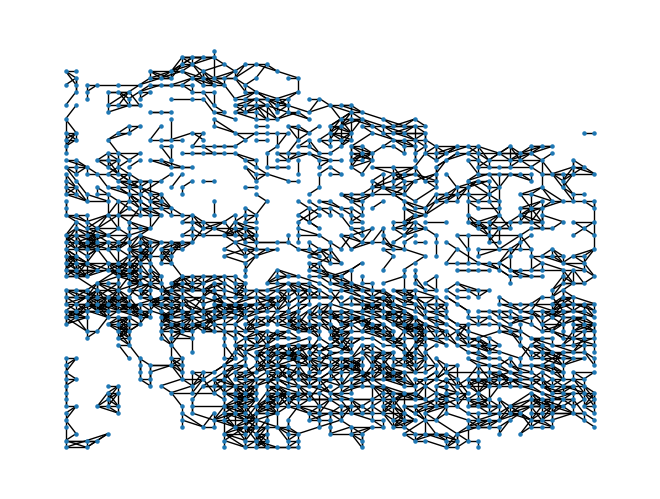

In [17]:
## Show networkx graph with coordinate positions

positions = [(centroid.x, centroid.y) for centroid in centroids]
pos = {node: coords for node, coords in zip(list(G.nodes()),positions)}
print("Nodes:",len(G.nodes), "\tEdges:",len(G.edges))
nx.draw(G, pos, node_size = 5)

Nodes: 267
Variables: ~801


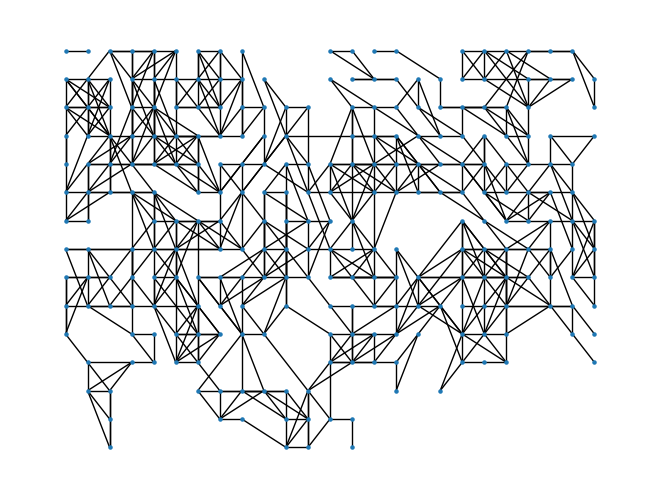

In [18]:
## Subset to lower right portion of the graph, 1/8th of original area

xlist, ylist = zip(*positions)
xlist = list(xlist)
ylist = list(ylist)
xmax = max(xlist)
xmin = min(xlist)
ymax = max(ylist)
ymin = min(ylist)
xmid = (xmax+xmin)/2
ymid = (ymax+3*ymin)/4

sub_nodes = [node for node in G.nodes if (pos[node][0] > xmid and pos[node][1] < ymid)]
sub_edges = [edge for edge in G.edges if (edge[0] in sub_nodes and edge[1] in sub_nodes)]

G = nx.Graph(sub_edges)
print(f"Nodes: {len(G.nodes)}")
print(f"Variables: ~{3*len(G.nodes)}")
nx.draw(G, pos, node_size = 5)

# Run Solver

In [13]:
results, sample = timed_cvxpy(G, seps = 7)

Solving the minimization...
                                     CVXPY                                     
                                     v1.5.3                                    
(CVXPY) Jul 08 11:22:32 AM: Your problem has 801 variables, 270 constraints, and 0 parameters.
(CVXPY) Jul 08 11:22:32 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 08 11:22:32 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 08 11:22:32 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 08 11:22:32 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Jul 08 11:22:33 AM: Compiling pro

/Users/rditlscd/mambaforge/envs/cvxpy_env/lib/python3.12/site-packages/cvxpy/problems/problem.py:158: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


(CVXPY) Jul 08 11:22:33 AM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 08 11:22:33 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Jul 08 11:22:33 AM: Applying reduction SCIP
(CVXPY) Jul 08 11:22:34 AM: Finished problem compilation (took 1.529e+00 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Jul 08 11:22:34 AM: Invoking solver SCIP  to obtain a solution.
presolving:
(round 1, fast)       7140 del vars, 7140 del conss, 0 add conss, 14280 chg bounds, 0 chg sides, 0 chg coeffs, 1428 upgd conss, 0 impls, 267 clqs
(round 2, fast)       8568 del vars, 8568 del conss, 0 add conss, 14280 chg bounds, 0 chg sides, 0 chg coeffs, 1428 upgd conss, 0 impls, 267 clqs
(round 3, exhaustive) 8568 del vars, 8569 del conss, 0 add conss, 14280 chg bounds, 0 chg sides, 0 chg coeffs, 1695 upgd 

In [18]:
## Save results
with open(model_folder+'cvxpy_results.pkl', 'wb') as handle:
    pickle.dump(results, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [3]:
## Load results
with open(model_folder+'cvxpy_results.pkl', 'rb') as handle:
    results = pickle.load(handle)

# Visualize Results

In [10]:
mydict = results
group_1 = mydict['group_1']
group_2 = mydict['group_2']
illegal_edges = mydict['illegal_edges']
sep_group = mydict['sep_group']


Visualizing output...
	Output stored in ../../reports/figures/cvxpy_separated_network.png


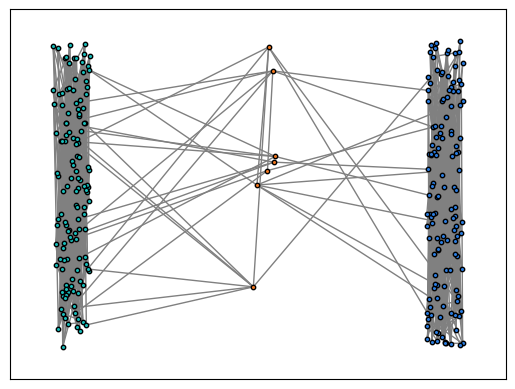

In [11]:
visualize_results(G,group_1,group_2,sep_group,illegal_edges, save=True, filename="cvxpy_separated_network.png")


Output stored in ../../reports/figures/cvxpy_groups.png


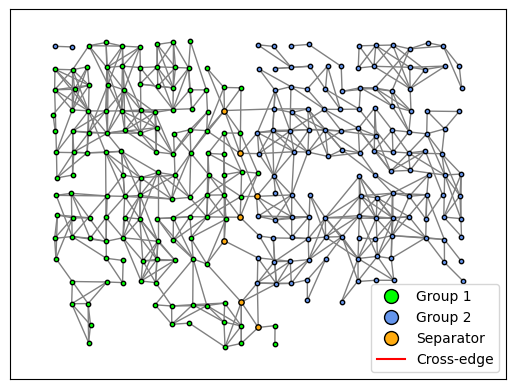

In [12]:
visualize_groups(G, pos, group_1, group_2, illegal_edges, sep_group, noise=True, save=True, filename = "cvxpy_groups.png")

# Time Build

In [21]:
tolerance = 1
seps = 7

start = time()
binary_vars = [cp.Variable(shape=3,boolean=True) for node in G.nodes()]
node2ind = {n: i for i,n in enumerate(G.nodes())}
ind2node = {i: n for i,n in enumerate(G.nodes())}
if tolerance is None:
    tolerance = 1


## Add constraints
constr = []

G1 = cp.sum([binary_vars[i][0] for i in range(len(binary_vars))])
G2 = cp.sum([binary_vars[i][1] for i in range(len(binary_vars))])
constr.append(G1 - G2 <= tolerance)
constr.append(G1 - G2 >= -tolerance)

S = cp.sum([binary_vars[i][2] for i in range(len(binary_vars))])
constr.append(S == seps)

for i in range(len(binary_vars)):
    constr.append(cp.sum(binary_vars[i]) == 1)

## Set up objective
edge_sum_1 = []
edge_sum_2 = []
edge_sum_3 = []
edge_sum_4 = []
for a, b in G.edges():
    if a != b:
        edge_sum_1.append(cp.square(binary_vars[node2ind[a]][0] + binary_vars[node2ind[b]][1]))
        edge_sum_2.append(cp.square(binary_vars[node2ind[a]][1] + binary_vars[node2ind[b]][0]))
        edge_sum_3.append(cp.square(binary_vars[node2ind[a]][2]))
        edge_sum_4.append(cp.square(binary_vars[node2ind[b]][2]))

cost = cp.sum(edge_sum_1) + cp.sum(edge_sum_2) + cp.sum(edge_sum_3) + cp.sum(edge_sum_4)
end = time()
print(f"Build Time: {end-start}")

Build Time: 0.11076784133911133
